# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: 
#!pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

C:\Users\alhal\anaconda3\envs\torchtest\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 6121.31it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'When was the first large language model created (be consise, 2-3 sentences)'   # TODO (you): your own short prompt
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [2215, 373, 262, 717, 1588, 3303, 2746, 2727, 357, 1350, 762, 786, 11, 362, 12, 18, 13439, 8]
  pos 0: id   2215 -> 'When'
  pos 1: id    373 -> ' was'
  pos 2: id    262 -> ' the'
  pos 3: id    717 -> ' first'
  pos 4: id   1588 -> ' large'
  pos 5: id   3303 -> ' language'
  pos 6: id   2746 -> ' model'
  pos 7: id   2727 -> ' created'
  pos 8: id    357 -> ' ('
  pos 9: id   1350 -> 'be'
  pos 10: id    762 -> ' cons'
  pos 11: id    786 -> 'ise'
  pos 12: id     11 -> ','
  pos 13: id    362 -> ' 2'
  pos 14: id     12 -> '-'
  pos 15: id     18 -> '3'
  pos 16: id  13439 -> ' sentences'
  pos 17: id      8 -> ')'

embedded prompt shape (seq_len, dim): (18, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'When'       0.207
  ' was'       0.050
  ' the'       0.038
  ' first'     0.030
  ' large'     0.066
  ' language'  0.065
  ' model'     0.095
  ' created'   0.048
  ' ('         0.017
  'be'         0.076
  ' cons'      0.051
  'ise'        0.079
  ','    

## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

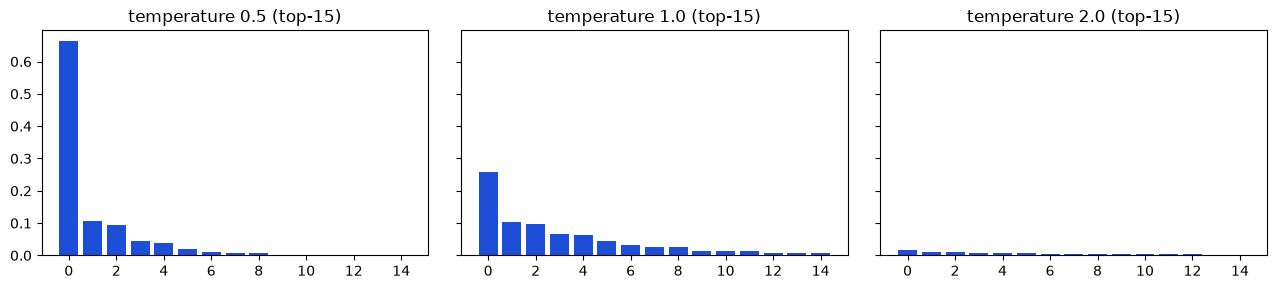

top token prob: temp 0.5 = 0.663, temp 1.0 = 0.258, temp 2.0 = 0.016


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp in [(1e-6, 1.0), (0.7, 1.0), (1.3, 0.9)]:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')
# TODO (you): for each row, write what you predicted versus what you see.

#Temp 1e-06 top-p 1.0: I predicted that the distribution would centralize around one token, with low entropy and a maximum probability near 1, 
# and it ended up essentially doing that, with the almost 0 temperature causing its probability to centralize around 1 token.

#Temp 0.7 top-p 1.0: For this one I predicted a sharper distribution, with lower entropy and a higher maximum probability than the prior temperature.
# Since top-p is set to 1.0, I expected it to keep most if not all of the vocabulary options. Overall my prediction was right. Lower temperature 
# narrows the probability to the most likely token options, meanwhile a top-p of 1 keeps the whole vocabulary

#Temp 1.3 top-p 0.9: For this last prediction, I figured there would be a more flat distribution, increasing entropy and decreasing maximum
# probability. The Top-p being 0.9 should then remove the low-probability tokens. My prediction was accurate. Higher temperature produced a more
# flat distribution, and top-p being 0.9 reduced the total vocabulary down to 2,109 tokens.


temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: entropy 2.024, max prob 0.466, nucleus keeps 50258 tokens
temp 1.3    top-p 0.9: entropy 5.824, max prob 0.120, nucleus keeps 2109 tokens


In [5]:
#Evaluating three responses

def generateText(prompt, temperature=None, top_p=None, top_k=None):
    inputs = tok(prompt, return_tensors='pt')
    if temperature == 0:
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=50, do_sample=False, pad_token_id=tok.eos_token_id)
    else:
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=50, do_sample=True, temperature=temperature,
                top_p=top_p if top_p is not None else 1.0, top_k=top_k if top_k is not None else 0, pad_token_id=tok.eos_token_id)

    return tok.decode(output[0], skip_special_tokens=True)


prompt = "Describe the basic concept of a large language model"

print("PROMPT:")
print(prompt)

print("\n- Temperature 0")
print(generateText(prompt, temperature=0))

print("\n- Temperature 0.7, top-p 0.9")
print(generateText(prompt, temperature=0.7, top_p=0.9))

print("\n- Temperature 1.2, top-k 50")
print(generateText(prompt, temperature=1.2, top_k=50))



PROMPT:
Describe the basic concept of a large language model

- Temperature 0
Describe the basic concept of a large language model.


















































- Temperature 0.7, top-p 0.9
Describe the basic concept of a large language model, and describe the basic characteristics of the language itself.

- Temperature 1.2, top-k 50
Describe the basic concept of a large language model developed earlier that is, the typeifier that makes semantic representations of objects can be a lot of work. Here a large language model has an idea of what kinds of expressions are possible for a small language model. But the basic concepts that the model can


## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [39]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, .1)
print('Vocab total size:', len(p0))
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)')
# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.

removedTokens, keptTokens = top_p(p, 0.2)
print('Tokens kept with top-p=0.2:', keptTokens)
print('Probability sum after top-p filter:', removedTokens.sum())

# I chose to look at a model with a temperature of 0.1 and a top-p of 0.2, this model would be very repetitive as is demonstrated by the tokens kept
# Using such a low top-p value will cause the model to drop most of its vocabulary, and combined with the temperature setting equal to 0.1, probabilty 
# is massively shifted towards one token as demonstrated by the top token probability of 0.999832. This could be prevented and fixed by using higher values
# for both temperature and top-p, expanding token selection probability and total vocabulary respectively.

Vocab total size: 50257
temp -> 0: top token prob = 0.999832 (greedy collapse)
Tokens kept with top-p=0.2: 3
Probability sum after top-p filter: 1.0


## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).